<a href="https://colab.research.google.com/github/cs24dse007-boop/CSL701-CS04-Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_no2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Name:Omkar Madhukar Bhalekar

Roll No:cs04

Batch=cs1

Aim: To implement a Simple Linear Regression model using Python and predict MPG from Horsepower using OLS.

**Objectives**
*   Understand SLR
*   Load/preprocess dataset
*   Perform EDA
*   Compute OLS coefficients
*   Evaluate with SSE, MSE, R²
*   Visualize regression and residual plots


**Software Requirements**
*   Python 3.x
*   Jupyter/Colab/VS Code
*   Libraries: pandas, numpy, matplotlib, seaborn














**Theory**

Linear regression models the relationship between a target continuous variable Y and an input feature vector X using a linear equation:

                  yˆ=w0+w1x1
In matrix form, including the bias/intercept term X0=1:

                  yˆ=Xw
To find the optimal weight vector wˆ, the **Ordinary Least Squares (OLS)** method minimizes the Sum of Squared Errors (SSE) between actual target values y and predicted values yˆ:

                  SSE=i=1Nyi-yˆi2=y-Xw
Solving for w analytically yields the normal equation:

                  wˆ=XTX-1XTy
Note: The inverse XTX-1 exists only if the matrix XTX is non-singular (i.e., its determinant is non-zero).

In [ ]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sea

In [ ]:
#Load Auto MPG dataset
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

In [ ]:
# Inspect data and Clean data
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# Clean data
df = df[['horsepower', 'mpg']].dropna()

First 5 rows:
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders   

In [ ]:
# Select horsepower (X) and mpg (Y)
X = df['horsepower'].values
Y = df['mpg'].values

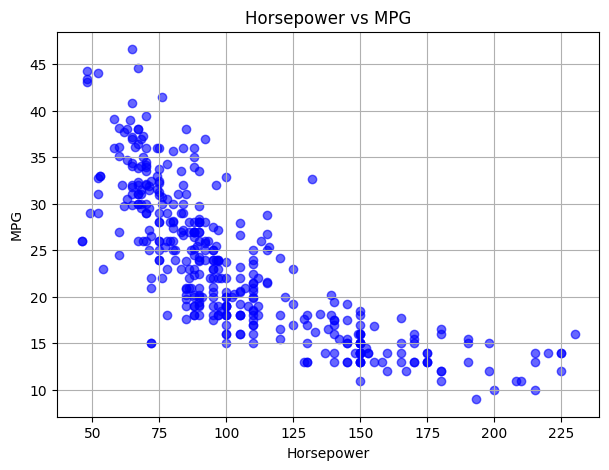

In [ ]:
# Scatter plot
plt.figure(figsize=(7,5))
plt.scatter(X, Y, color='blue', alpha=0.6)
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Horsepower vs MPG")
plt.grid(True)
plt.show()

In [ ]:
# Add bias term
X_bias = np.column_stack((np.ones(len(X)), X))

In [ ]:
# Compute correlation
correlation = np.corrcoef(X, Y)[0,1]
print("\nCorrelation Coefficient:", correlation)


Correlation Coefficient: -0.7784267838977756


In [ ]:
# Calculate OLS weights
weights = np.linalg.inv(X_bias.T @ X_bias) @ X_bias.T @ Y
intercept = weights[0]
slope = weights[1]

print("\nIntercept:", intercept)
print("Slope:", slope)


Intercept: 39.9358610211705
Slope: -0.15784473335365387


In [ ]:
# Predict values
Y_pred = X_bias @ weights

In [ ]:
# Compute residuals
residuals = Y - Y_pred

In [ ]:
# Calculate SSE
SSE = np.sum(residuals**2)
# Calculate MSE
MSE = SSE / len(Y)

# Calculate R²
SST = np.sum((Y - np.mean(Y))**2)
R2 = 1 - (SSE / SST)

print("\nPerformance Metrics")
print("-------------------")
print("SSE :", SSE)
print("MSE :", MSE)
print("R²  :", R2)


Performance Metrics
-------------------
SSE : 9385.915871932419
MSE : 23.943662938603108
R²  : 0.6059482578894348


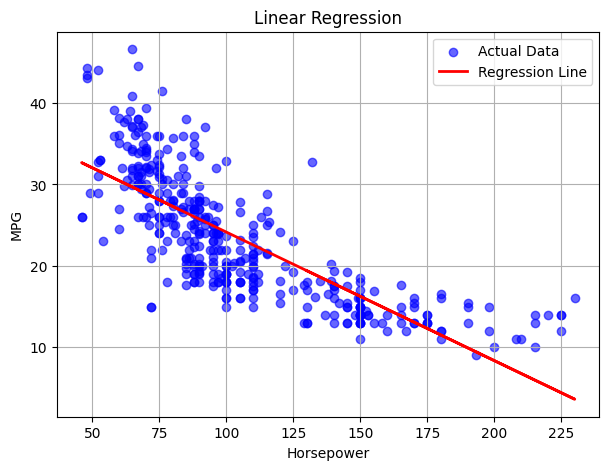

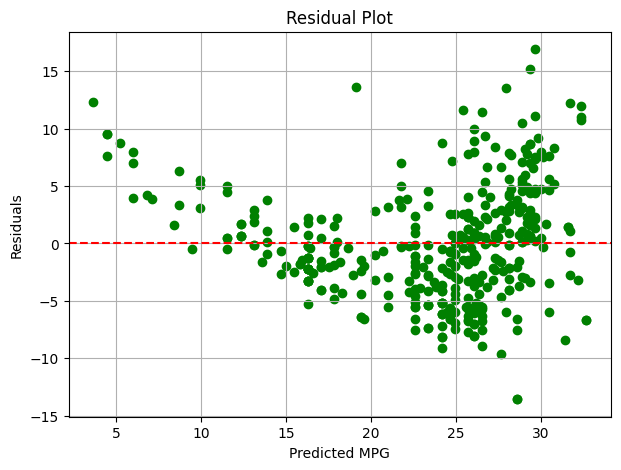

In [ ]:
# Regression line
plt.figure(figsize=(7,5))
plt.scatter(X, Y, color='blue', alpha=0.6, label='Actual Data')
plt.plot(X, Y_pred, color='red', linewidth=2, label='Regression Line')
plt.xlabel("Horsepower")
plt.ylabel("MPG")
plt.title("Linear Regression")
plt.legend()
plt.grid(True)
plt.show()

# Residual plot
plt.figure(figsize=(7,5))
plt.scatter(Y_pred, residuals, color='green')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.grid(True)
plt.show()

**Conclusion**

The experiment successfully implemented Simple Linear Regression using OLS. Horsepower showed a negative relationship with MPG, and evaluation metrics demonstrated reasonable predictive performance.
